# We Are Not Screwed
## An Economic Model for the Post-Labor Future

**Thesis:** As AI replaces human labor, humans transition from workers to investors. Companies see massive profit expansion from reduced labor costs, and those profits flow to shareholders as dividends. The question: is there enough wealth generated to sustain society through investment income?

We start with Amazon — real SEC EDGAR data, real financials, real scenarios.

In [ ]:
import sys
sys.path.insert(0, '.')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

from src.ingestion.edgar import EdgarClient, KNOWN_CIKS
from src.normalization.normalize import normalize_facts, compute_derived_fields
from src.models.labor import estimate_amazon_labor, AMAZON_HEADCOUNT
from src.models.scenario import run_scenario, SCENARIOS, ScenarioParams
from src.models.portfolio import (
    PORTFOLIO_COMPANIES, build_equal_weight_portfolio,
    build_custom_weight_portfolio, run_portfolio_scenario,
    find_income_milestone_year, find_total_income_milestone_year,
)

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

colors = {'conservative': '#2196F3', 'moderate': '#4CAF50', 'aggressive': '#FF9800', 'extreme': '#F44336'}

## 1. Pull Real Amazon Financials from SEC EDGAR

Live data from the SEC — the same filings Amazon submits to regulators. FY2025 was filed February 6, 2026.

In [9]:
cik = KNOWN_CIKS['AMZN']

with EdgarClient() as client:
    facts = client.extract_financials(cik, annual_only=True)
    by_year = normalize_facts(facts)

# Add derived fields
for year in by_year:
    by_year[year] = compute_derived_fields(by_year[year])

years = sorted(by_year.keys())
print(f'Loaded {len(years)} years of Amazon financials: {years[0]}-{years[-1]}')
print(f'FY{years[-1]} Revenue: ${by_year[years[-1]]["revenue"]/1e9:.1f}B')
print(f'FY{years[-1]} Operating Income: ${by_year[years[-1]]["operating_income"]/1e9:.1f}B')

Loaded 19 years of Amazon financials: 2007-2025
FY2025 Revenue: $716.9B
FY2025 Operating Income: $80.0B


## 2. Amazon's Growth Story — Revenue & Profits

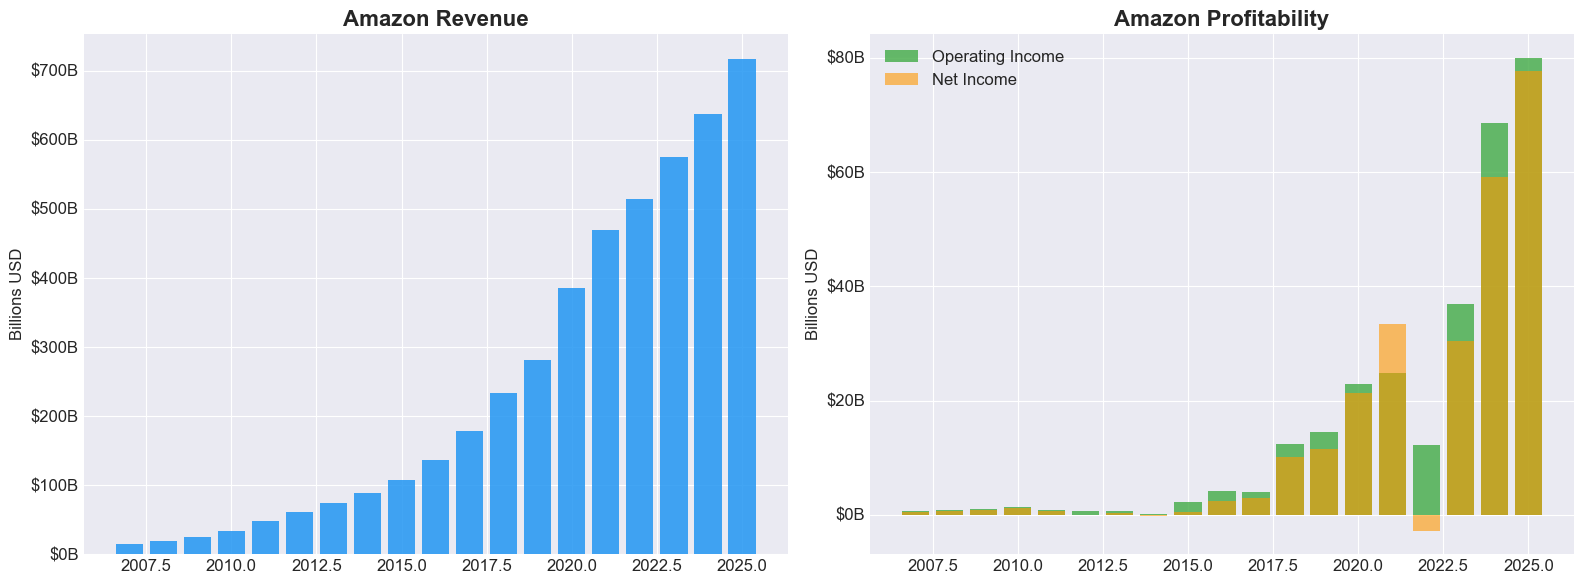

In [10]:
rev = [by_year[y].get('revenue', 0) / 1e9 for y in years]
op_inc = [by_year[y].get('operating_income', 0) / 1e9 for y in years]
net_inc = [by_year[y].get('net_income', 0) / 1e9 for y in years]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.bar(years, rev, color='#2196F3', alpha=0.85)
ax1.set_title('Amazon Revenue', fontsize=16, fontweight='bold')
ax1.set_ylabel('Billions USD')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))

ax2.bar(years, op_inc, color='#4CAF50', alpha=0.85, label='Operating Income')
ax2.bar(years, net_inc, color='#FF9800', alpha=0.6, label='Net Income')
ax2.set_title('Amazon Profitability', fontsize=16, fontweight='bold')
ax2.set_ylabel('Billions USD')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))
ax2.legend()

plt.tight_layout()
plt.show()

## 3. The Labor Cost Picture

Amazon employs ~1.56 million people. We estimate total labor cost using:
- Headcount from 10-K filings
- Blended compensation: ~70% warehouse workers ($40k avg) + ~30% corporate/tech ($160k avg)
- Benefits multiplier of 1.4x (BLS data)
- Stock-based compensation from EDGAR XBRL

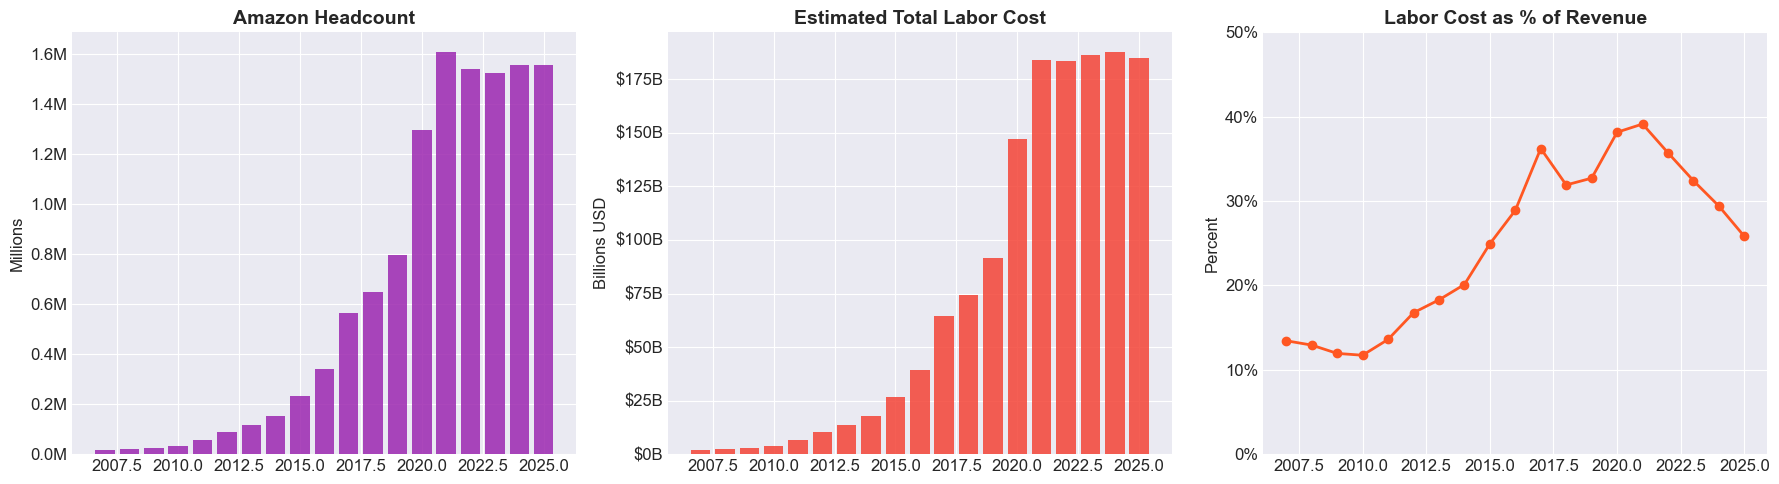


FY2025 Labor Summary:
  Headcount:              1,556,000
  Blended avg comp:    $   76,000.0
  Benefits multiplier:         1.40x
  Stock-based comp:    $       19.5B
  Total labor cost:    $      185.0B
  Labor % of revenue:         25.8%


In [11]:
labor_years = sorted(y for y in years if y in AMAZON_HEADCOUNT)
labor_estimates = {}
for y in labor_years:
    est = estimate_amazon_labor(y, by_year[y])
    if est:
        labor_estimates[y] = est

ly = sorted(labor_estimates.keys())
headcounts = [labor_estimates[y].headcount / 1e6 for y in ly]
labor_costs = [labor_estimates[y].total_labor_cost / 1e9 for y in ly]
labor_pct = [labor_estimates[y].labor_pct_of_revenue for y in ly]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.bar(ly, headcounts, color='#9C27B0', alpha=0.85)
ax1.set_title('Amazon Headcount', fontsize=14, fontweight='bold')
ax1.set_ylabel('Millions')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))

ax2.bar(ly, labor_costs, color='#F44336', alpha=0.85)
ax2.set_title('Estimated Total Labor Cost', fontsize=14, fontweight='bold')
ax2.set_ylabel('Billions USD')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))

ax3.plot(ly, labor_pct, 'o-', color='#FF5722', linewidth=2, markersize=6)
ax3.set_title('Labor Cost as % of Revenue', fontsize=14, fontweight='bold')
ax3.set_ylabel('Percent')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax3.set_ylim(0, 50)

plt.tight_layout()
plt.show()

latest = labor_estimates[ly[-1]]
print(f'\nFY{ly[-1]} Labor Summary:')
print(f'  Headcount:           {latest.headcount:>12,}')
print(f'  Blended avg comp:    ${latest.avg_compensation:>11,}')
print(f'  Benefits multiplier: {latest.benefits_multiplier:>12.2f}x')
print(f'  Stock-based comp:    ${latest.stock_based_comp/1e9:>11.1f}B')
print(f'  Total labor cost:    ${latest.total_labor_cost/1e9:>11.1f}B')
print(f'  Labor % of revenue:  {latest.labor_pct_of_revenue:>11.1f}%')

## 4. Scenario Engine: What Happens When AI Replaces Labor?

Four scenarios from conservative to extreme. Each is modeled with:

- **S-curve adoption ramp** — AI doesn't replace everyone overnight. Slow start, acceleration, plateau.
- **AI costs are NOT cheap** — they start high and decline over time (Moore's Law for compute)
- **Revenue grows** — companies aren't static over 30 years
- **Demand model** — this is the critical piece: if displaced workers have no income, they stop buying. Economy collapses. The investor model is what prevents this.

| Scenario | Labor Cut | Ramp | AI Cost/Worker | Revenue Growth | Supply Chain Cut | Div Payout |
|----------|-----------|------|---------------|---------------|-----------------|------------|
| Conservative | 25% | 20 yr | $80k (-15%/yr) | 4% | 15% | 30% |
| Moderate | 50% | 15 yr | $60k (-20%/yr) | 4% | 25% | 40% |
| Aggressive | 75% | 10 yr | $40k (-25%/yr) | 3% | 40% | 50% |
| Extreme | 95% | 8 yr | $30k (-30%/yr) | 2% | 60% | 60% |

**Supply Chain Cut**: Non-labor operating costs (goods, shipping, infrastructure) also drop as the entire economy automates.

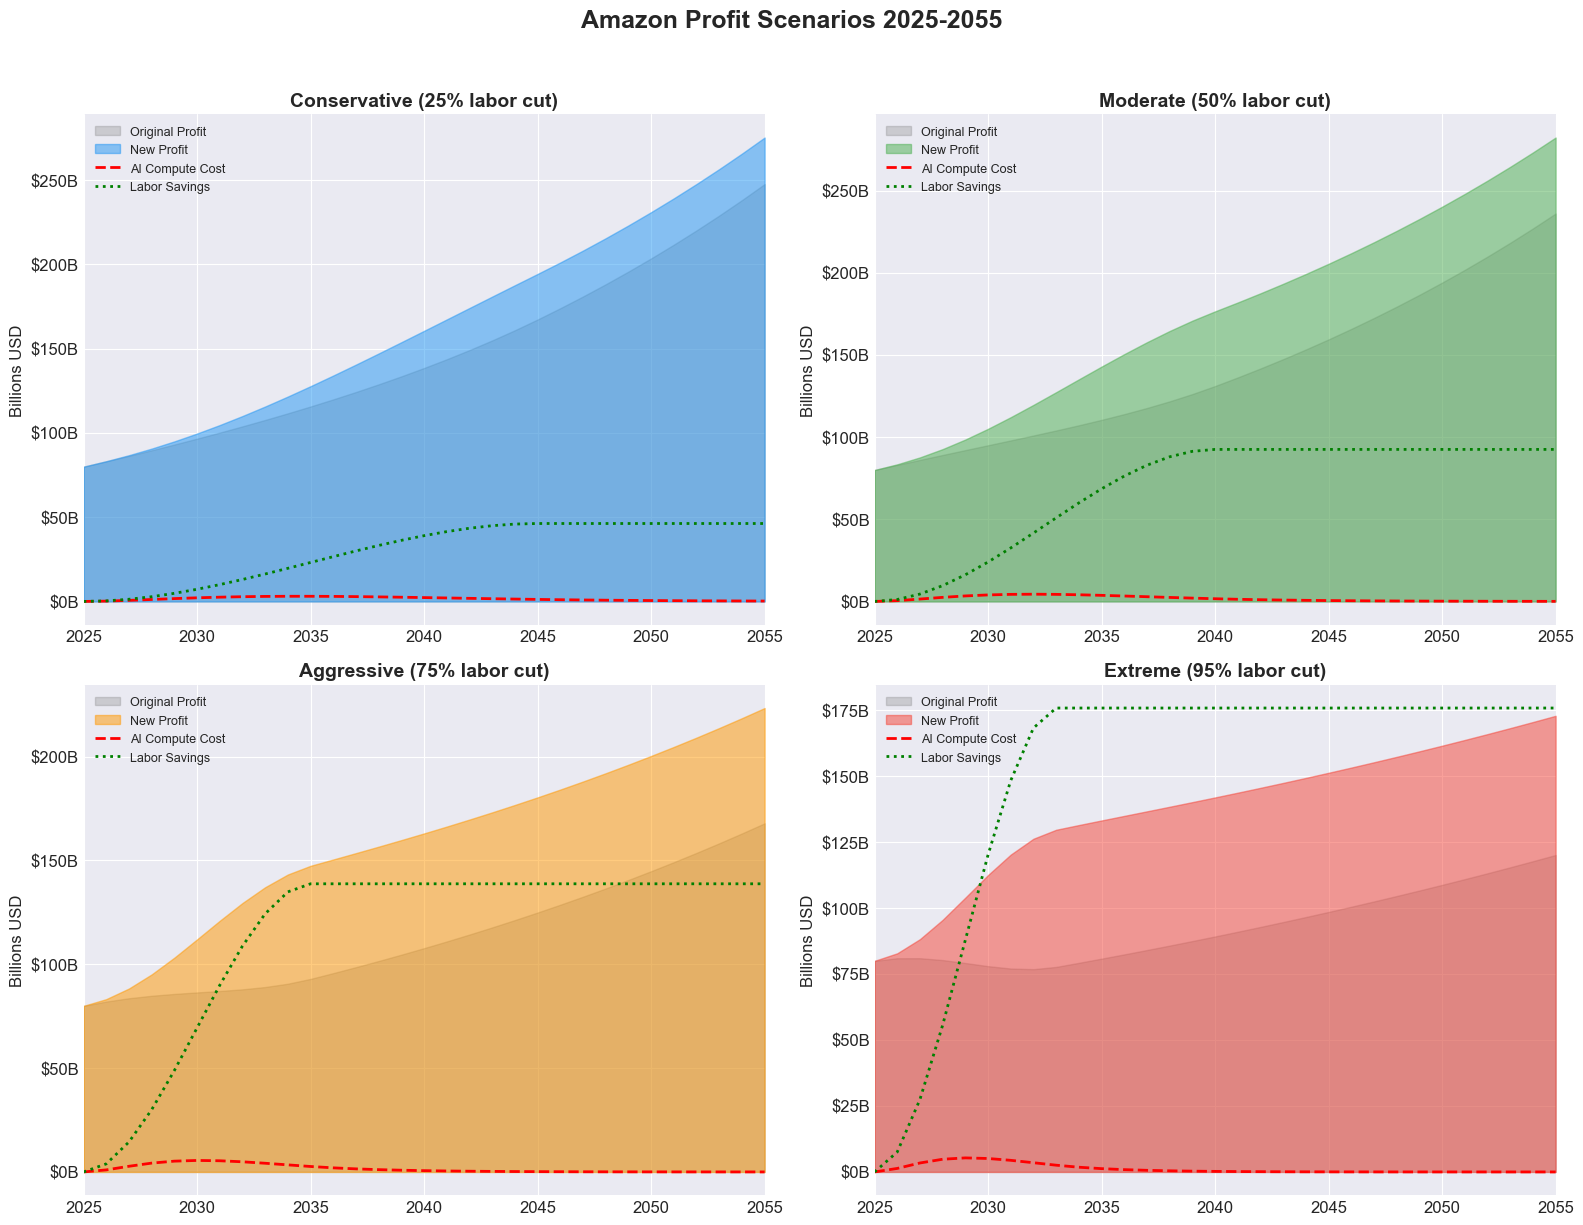

In [12]:
base_year = max(by_year.keys())
base_data = by_year[base_year]
labor = estimate_amazon_labor(base_year, base_data)

results = {}
for name, params in SCENARIOS.items():
    params.base_year = base_year
    results[name] = run_scenario(params, 'Amazon', base_data, labor)

# Plot: Profit trajectory across scenarios — full 30 year horizon
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, (name, result) in zip(axes.flat, results.items()):
    proj_years = [p.year for p in result.projections]
    orig_profit = [p.original_profit / 1e9 for p in result.projections]
    new_profit = [p.new_profit / 1e9 for p in result.projections]
    ai_cost = [p.ai_compute_cost / 1e9 for p in result.projections]
    labor_savings = [p.labor_savings / 1e9 for p in result.projections]
    
    ax.fill_between(proj_years, 0, orig_profit, alpha=0.3, color='gray', label='Original Profit')
    ax.fill_between(proj_years, 0, new_profit, alpha=0.5, color=colors[name], label='New Profit')
    ax.plot(proj_years, ai_cost, '--', color='red', linewidth=2, label='AI Compute Cost')
    ax.plot(proj_years, labor_savings, ':', color='green', linewidth=2, label='Labor Savings')
    
    ax.set_title(f'{name.title()} ({result.params.labor_reduction_pct:.0%} labor cut)', 
                fontsize=14, fontweight='bold')
    ax.set_ylabel('Billions USD')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))
    ax.legend(fontsize=9, loc='upper left')
    ax.set_xlim(base_year, base_year + 30)

fig.suptitle(f'Amazon Profit Scenarios {base_year}-{base_year+30}', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. The AI Cost Curve — This Is Not Free

A critical variable: today's AI costs are heavily subsidized. What does it actually cost to replace a human worker with AI compute?

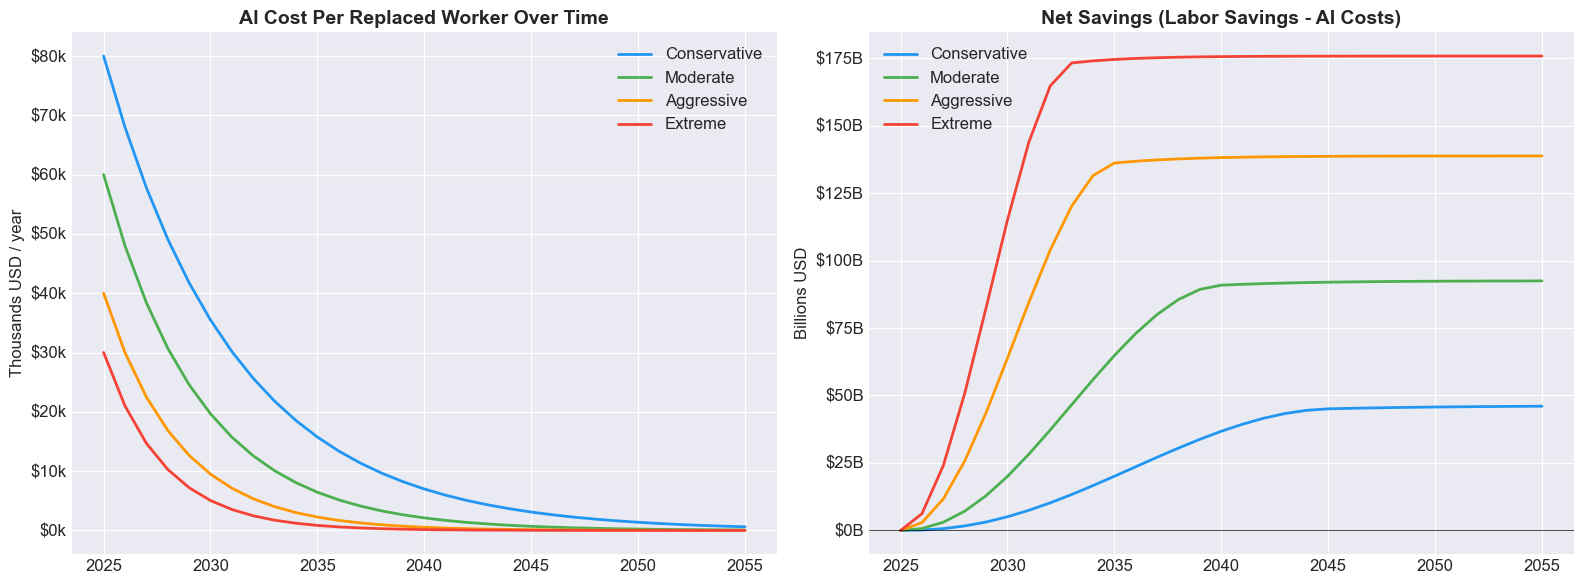

Note: AI adoption follows an S-curve ramp — slow start, acceleration, then plateau.
Conservative ramps over 20 years, Extreme over just 8 years (AGI scenario).


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for name, result in results.items():
    proj_years = [p.year for p in result.projections]
    ai_per_worker = [p.ai_cost_per_worker_this_year / 1000 for p in result.projections]
    ax1.plot(proj_years, ai_per_worker, '-', color=colors[name], linewidth=2, label=f'{name.title()}')

ax1.set_title('AI Cost Per Replaced Worker Over Time', fontsize=14, fontweight='bold')
ax1.set_ylabel('Thousands USD / year')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
ax1.legend()

# Net savings (labor savings minus AI costs) — shows the ramp
for name, result in results.items():
    proj_years = [p.year for p in result.projections]
    net = [p.net_savings / 1e9 for p in result.projections]
    ax2.plot(proj_years, net, '-', color=colors[name], linewidth=2, label=f'{name.title()}')

ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_title('Net Savings (Labor Savings - AI Costs)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Billions USD')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))
ax2.legend()

plt.tight_layout()
plt.show()

print('Note: AI adoption follows an S-curve ramp — slow start, acceleration, then plateau.')
print('Conservative ramps over 20 years, Extreme over just 8 years (AGI scenario).')

## 6. The Dividend Projection

Amazon currently pays **zero dividends**. But in a world where profits double or triple from AI cost savings, massive dividend payouts become inevitable — shareholders will demand it.

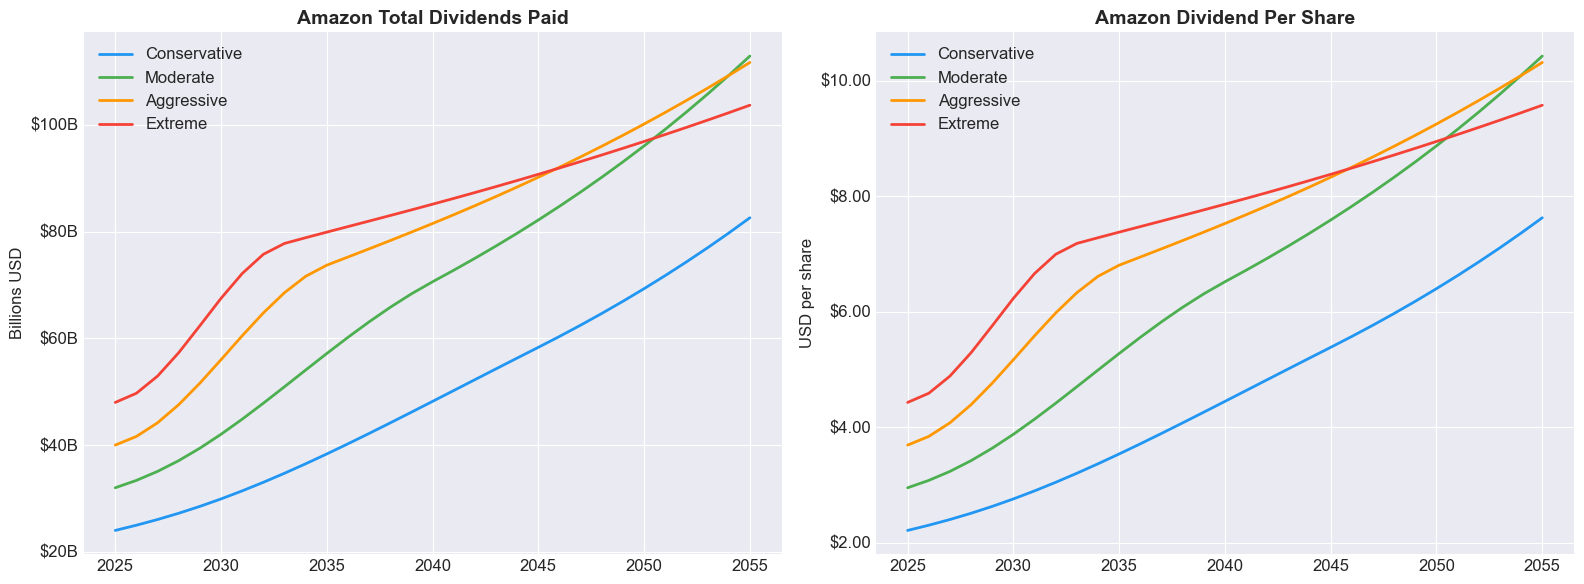

The S-curve ramp is visible — dividends accelerate as AI adoption picks up steam,
then plateau as labor reduction reaches its ceiling.


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for name, result in results.items():
    proj_years = [p.year for p in result.projections]
    divs = [p.dividends_total / 1e9 for p in result.projections]
    dps = [p.dividend_per_share for p in result.projections]
    
    ax1.plot(proj_years, divs, '-', color=colors[name], linewidth=2, label=f'{name.title()}')
    ax2.plot(proj_years, dps, '-', color=colors[name], linewidth=2, label=f'{name.title()}')

ax1.set_title('Amazon Total Dividends Paid', fontsize=14, fontweight='bold')
ax1.set_ylabel('Billions USD')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))
ax1.legend()

ax2.set_title('Amazon Dividend Per Share', fontsize=14, fontweight='bold')
ax2.set_ylabel('USD per share')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.2f}'))
ax2.legend()

plt.tight_layout()
plt.show()

print('The S-curve ramp is visible — dividends accelerate as AI adoption picks up steam,')
print('then plateau as labor reduction reaches its ceiling.')

## 7. Nobody Invests in Just One Company — The Portfolio Model

Amazon alone requires millions to generate a living income — and it currently pays zero dividends. But nobody invests in one company. A real portfolio includes:

- **AI Infrastructure** (NVIDIA) — they *profit* from every AI replacement
- **Tech Giants** (Microsoft, Apple, Google, Meta, Amazon) — huge labor forces, massive profit potential
- **Traditional Dividend Payers** (JPMorgan, J&J, P&G, Exxon) — already returning capital today

The question: what does a $500k, $1M, or $2M diversified portfolio generate in annual income as AI transforms these companies over 30 years?

In [15]:
# Show the portfolio companies
print(f'{"Ticker":<8} {"Company":<22} {"Sector":<22} {"Revenue":>12} {"Headcount":>12} '
      f'{"Labor Cost":>12} {"Labor%Rev":>10} {"Curr Div":>10} {"Price":>8}')
print('=' * 120)

total_rev = 0
total_hc = 0
total_labor = 0

for co in PORTFOLIO_COMPANIES:
    total_rev += co.revenue
    total_hc += co.headcount
    total_labor += co.estimated_labor_cost
    curr_yield = (co.current_dividend_per_share / co.share_price * 100) if co.share_price else 0
    print(f'{co.ticker:<8} {co.name:<22} {co.sector:<22} '
          f'${co.revenue/1e9:>10.1f}B {co.headcount:>11,} '
          f'${co.estimated_labor_cost/1e9:>10.1f}B {co.labor_pct_of_revenue:>9.1f}% '
          f'${co.current_dividend_per_share:>8.2f} ${co.share_price:>6.0f}')

print('=' * 120)
print(f'{"TOTAL":<8} {"10 Companies":<22} {"":22} '
      f'${total_rev/1e9:>10.1f}B {total_hc:>11,} '
      f'${total_labor/1e9:>10.1f}B {total_labor/total_rev*100:>9.1f}%')
print(f'\nThese 10 companies employ {total_hc/1e6:.1f}M people with ~${total_labor/1e9:.0f}B in labor costs.')
print(f'That labor cost is the profit expansion opportunity when AI takes over.')

Ticker   Company                Sector                      Revenue    Headcount   Labor Cost  Labor%Rev   Curr Div    Price
NVDA     NVIDIA                 AI Infrastructure      $     130.5B      36,000 $      14.4B      11.0% $    0.04 $   130
MSFT     Microsoft              Technology             $     254.2B     228,000 $      55.0B      21.6% $    3.32 $   415
AAPL     Apple                  Technology             $     391.0B     161,000 $      42.0B      10.7% $    1.00 $   235
GOOGL    Alphabet               Technology             $     350.0B     183,000 $      56.0B      16.0% $    0.80 $   185
AMZN     Amazon                 Technology / Retail    $     716.9B   1,556,000 $     185.0B      25.8% $    0.00 $   230
META     Meta Platforms         Technology             $     164.5B      74,000 $      24.5B      14.9% $    2.00 $   600
JPM      JPMorgan Chase         Financial Services     $     180.0B     313,000 $      50.0B      27.8% $    5.00 $   250
JNJ      Johnson & Jo

## 8. Portfolio Income Over 30 Years

Now the real question. You invest $500k, $1M, or $2M across these 10 companies equally. What does your annual dividend income look like over 30 years under each scenario?

This includes **existing dividends** (Microsoft, Apple, JPMorgan etc. already pay) **plus new dividends** from AI-driven profit expansion.

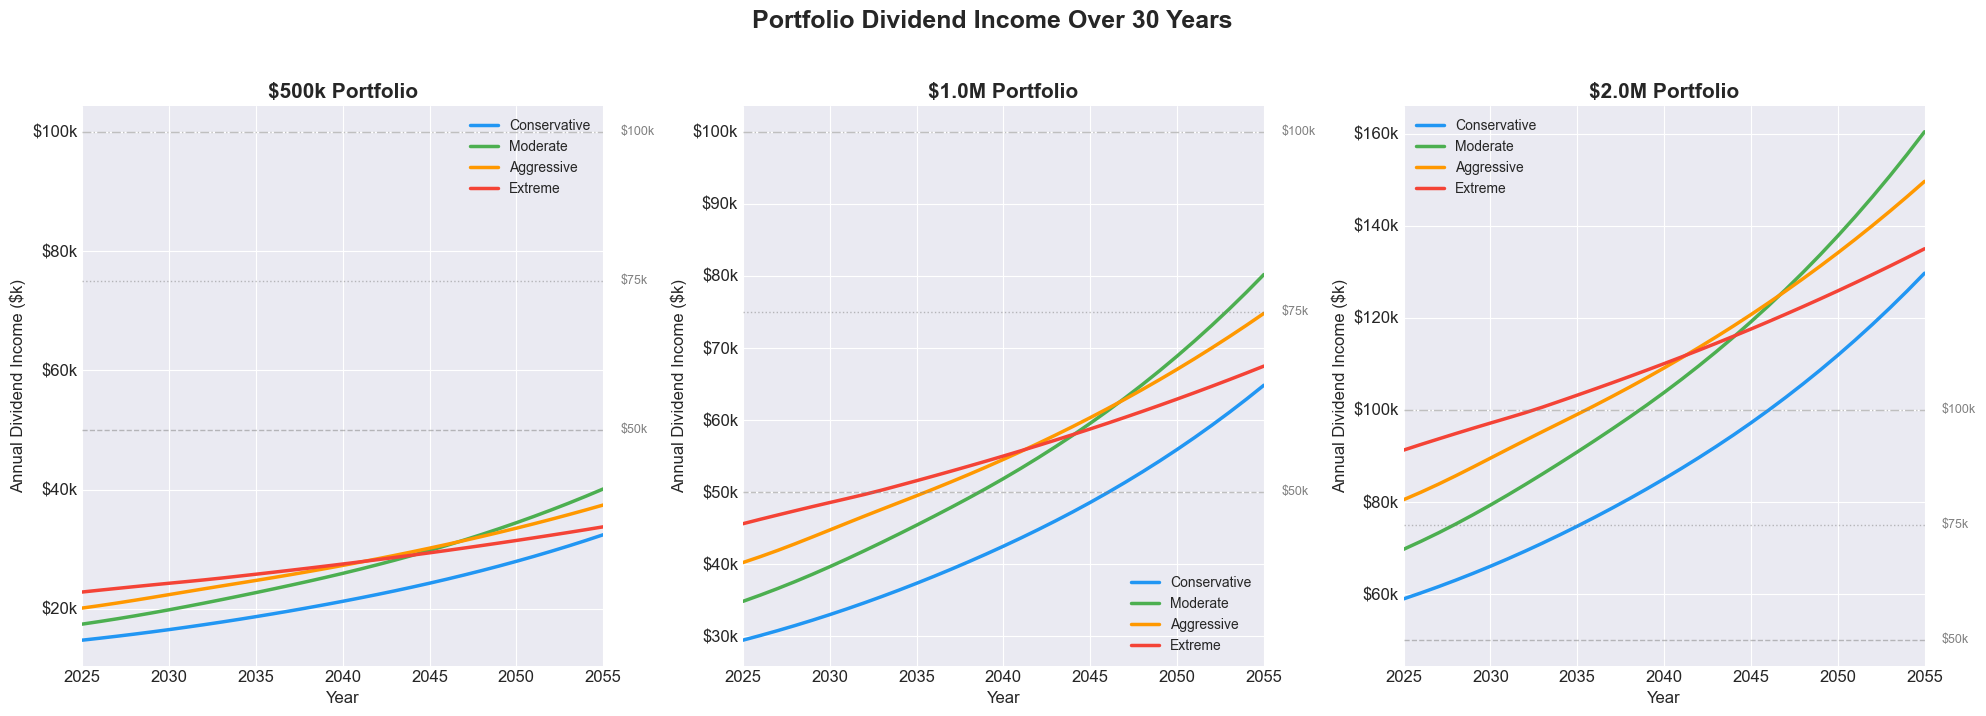

In [16]:
investment_levels = [500_000, 1_000_000, 2_000_000]
portfolio_results = {}

for scenario_name, params in SCENARIOS.items():
    params.base_year = base_year
    for inv_amount in investment_levels:
        allocs = build_equal_weight_portfolio(PORTFOLIO_COMPANIES, inv_amount)
        pr = run_portfolio_scenario(params, scenario_name, allocs)
        portfolio_results[(scenario_name, inv_amount)] = pr

# Big chart: annual income over 30 years, all scenarios, $1M investment
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, inv_amount in zip(axes, investment_levels):
    inv_label = f'${inv_amount/1e6:.1f}M' if inv_amount >= 1e6 else f'${inv_amount/1e3:.0f}k'
    
    for scenario_name in SCENARIOS:
        pr = portfolio_results[(scenario_name, inv_amount)]
        yrs = [yr.year for yr in pr.yearly_results]
        income = [yr.annual_income / 1000 for yr in pr.yearly_results]
        ax.plot(yrs, income, '-', color=colors[scenario_name], linewidth=2.5,
               label=f'{scenario_name.title()}')
    
    # Income milestone lines
    for milestone, ls in [(50, '--'), (75, ':'), (100, '-.')]:
        ax.axhline(y=milestone, color='gray', linestyle=ls, alpha=0.5, linewidth=1)
        ax.text(base_year + 31, milestone, f'${milestone}k', fontsize=9, 
               color='gray', va='center')
    
    ax.set_title(f'{inv_label} Portfolio', fontsize=15, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Annual Dividend Income ($k)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
    ax.set_xlim(base_year, base_year + 30)
    ax.legend(fontsize=10)

fig.suptitle('Portfolio Dividend Income Over 30 Years', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. When Does the Music Start? — Income Milestones

When does each investment level hit $50k, $75k, and $100k in annual dividend income? This is the timeline question — we don't know exactly when AI gets good enough, but we can see the trajectory.

In [17]:
milestones = [50_000, 75_000, 100_000]

print(f'When does your portfolio hit income milestones?')
print(f'\nDividend Income Only:')
print(f'{"Investment":<14} {"Scenario":<16} {"$50k/yr":>10} {"$75k/yr":>10} {"$100k/yr":>10}')
print('=' * 62)

for inv_amount in investment_levels:
    inv_label = f'${inv_amount/1e6:.1f}M' if inv_amount >= 1e6 else f'${inv_amount/1e3:.0f}k'
    for scenario_name in SCENARIOS:
        pr = portfolio_results[(scenario_name, inv_amount)]
        milestone_years = []
        for target in milestones:
            yr = find_income_milestone_year(pr, target)
            milestone_years.append(str(yr) if yr else 'Beyond 2055')
        print(f'{inv_label:<14} {scenario_name.title():<16} '
              f'{milestone_years[0]:>10} {milestone_years[1]:>10} {milestone_years[2]:>10}')
    print()

print(f'Total Return (Dividends + Capital Gains @ 4% SWR):')
print(f'{"Investment":<14} {"Scenario":<16} {"$50k/yr":>10} {"$75k/yr":>10} {"$100k/yr":>10}')
print('=' * 62)

for inv_amount in investment_levels:
    inv_label = f'${inv_amount/1e6:.1f}M' if inv_amount >= 1e6 else f'${inv_amount/1e3:.0f}k'
    for scenario_name in SCENARIOS:
        pr = portfolio_results[(scenario_name, inv_amount)]
        milestone_years = []
        for target in milestones:
            yr = find_total_income_milestone_year(pr, target)
            milestone_years.append(str(yr) if yr else 'Beyond 2055')
        print(f'{inv_label:<14} {scenario_name.title():<16} '
              f'{milestone_years[0]:>10} {milestone_years[1]:>10} {milestone_years[2]:>10}')
    print()

print('Capital gains dramatically accelerate the timeline — especially for lower investment levels.')

When does your portfolio hit income milestones?

Investment     Scenario            $50k/yr    $75k/yr   $100k/yr
$500k          Conservative     Beyond 2055 Beyond 2055 Beyond 2055
$500k          Moderate         Beyond 2055 Beyond 2055 Beyond 2055
$500k          Aggressive       Beyond 2055 Beyond 2055 Beyond 2055
$500k          Extreme          Beyond 2055 Beyond 2055 Beyond 2055

$1.0M          Conservative           2047 Beyond 2055 Beyond 2055
$1.0M          Moderate               2039       2053 Beyond 2055
$1.0M          Aggressive             2036 Beyond 2055 Beyond 2055
$1.0M          Extreme                2033 Beyond 2055 Beyond 2055

$2.0M          Conservative           2025       2036       2047
$2.0M          Moderate               2025       2028       2039
$2.0M          Aggressive             2025       2025       2036
$2.0M          Extreme                2025       2025       2033

Key: Year when annual dividend income first reaches each threshold.
"Beyond 2055" me

## 10. Where Does the Income Come From? — Portfolio Breakdown

Not all companies contribute equally. AI infrastructure providers like NVIDIA profit from the transition itself. Traditional dividend payers provide a steady base. Tech giants provide the upside.

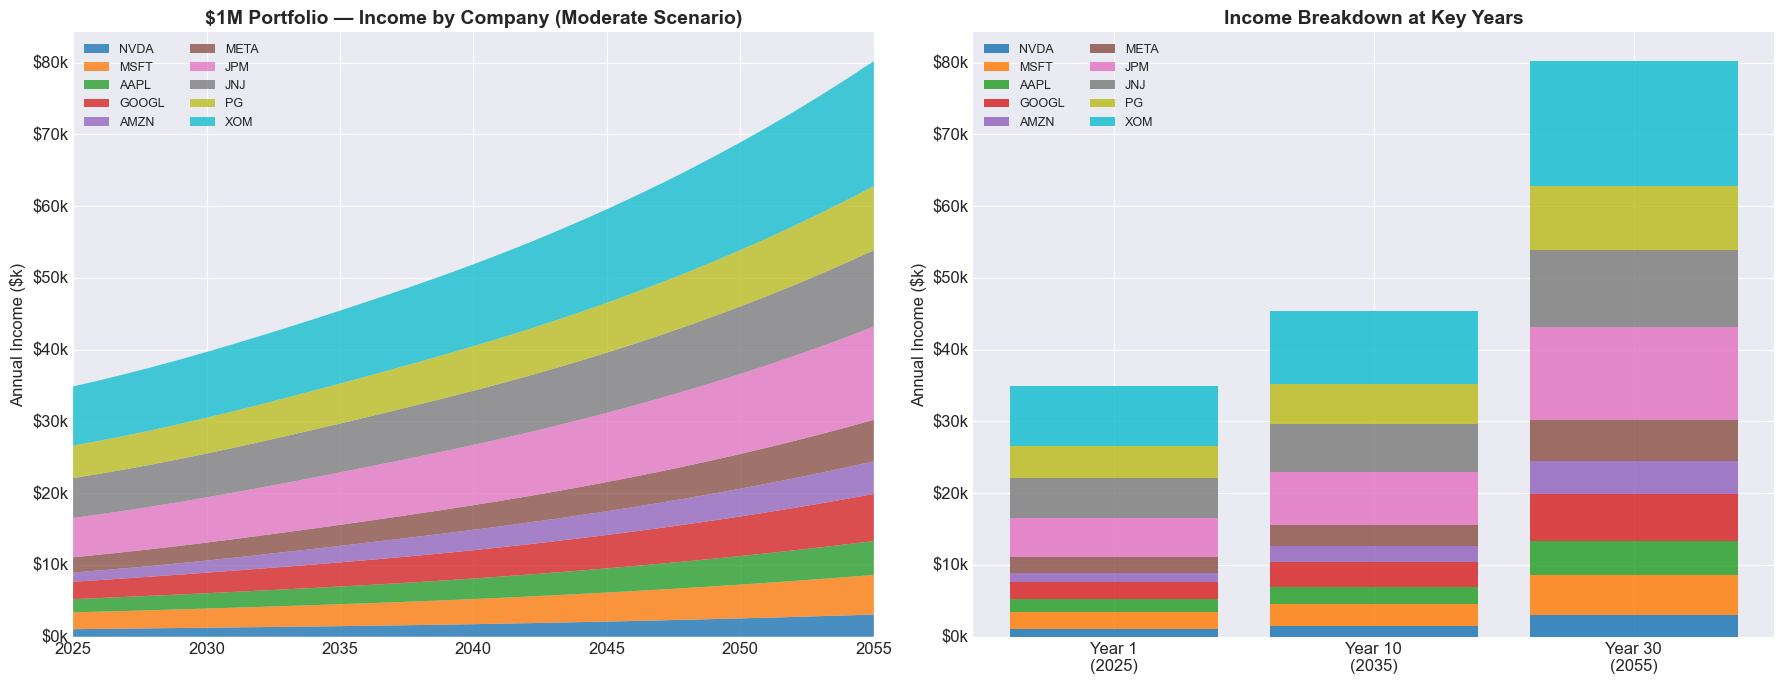

In [18]:
# Stacked area chart: income breakdown by company for $1M moderate scenario
pr = portfolio_results[('moderate', 1_000_000)]
yrs = [yr.year for yr in pr.yearly_results]
tickers = [co.ticker for co in PORTFOLIO_COMPANIES]

# Build stacked data
company_incomes = {t: [] for t in tickers}
for yr_result in pr.yearly_results:
    for t in tickers:
        company_incomes[t].append(yr_result.company_dividends.get(t, 0) / 1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Stacked area
palette = plt.cm.tab10(np.linspace(0, 1, len(tickers)))
ax1.stackplot(yrs, *[company_incomes[t] for t in tickers], 
              labels=tickers, colors=palette, alpha=0.8)
ax1.set_title('$1M Portfolio — Income by Company (Moderate Scenario)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Annual Income ($k)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
ax1.legend(loc='upper left', fontsize=9, ncol=2)
ax1.set_xlim(base_year, base_year + 30)

# Year 1 vs Year 10 vs Year 30 comparison
compare_years = [0, 10, 30]
compare_labels = [f'Year 1\n({base_year})', f'Year 10\n({base_year+10})', f'Year 30\n({base_year+30})']
x_pos = np.arange(len(compare_years))
bar_width = 0.08
bottom_vals = [np.zeros(len(compare_years)) for _ in tickers]

for i, t in enumerate(tickers):
    vals = [company_incomes[t][cy] for cy in compare_years]
    bottoms = np.zeros(len(compare_years))
    for j in range(i):
        bottoms += np.array([company_incomes[tickers[j]][cy] for cy in compare_years])
    ax2.bar(x_pos, vals, bottom=bottoms, color=palette[i], label=t, alpha=0.85)

ax2.set_title('Income Breakdown at Key Years', fontsize=14, fontweight='bold')
ax2.set_ylabel('Annual Income ($k)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
ax2.set_xticks(x_pos)
ax2.set_xticklabels(compare_labels)
ax2.legend(loc='upper left', fontsize=9, ncol=2)

plt.tight_layout()
plt.show()

## 11. Capital Gains — People Buy and Sell Stock

Dividends are only half the story. In reality, investors also generate income by **selling shares that have appreciated in value** — just like today. As AI drives profit expansion, share prices rise (P/E stays constant, earnings grow). An investor can sell a portion of their holdings each year for income.

We model this using the **4% safe withdrawal rate** — the well-studied approach from retirement planning. Each year, the investor can safely withdraw 4% of their portfolio's market value. Dividends cover part of that; selling appreciated shares covers the rest.

This is how most people actually invest. Amazon pays zero dividends today, but investors have made fortunes from price appreciation.

In [ ]:
# Portfolio value and total return (dividends + capital gains)
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Left: Portfolio value growth
ax = axes[0]
for scenario_name in SCENARIOS:
    pr = portfolio_results[(scenario_name, 1_000_000)]
    yrs = [yr.year for yr in pr.yearly_results]
    vals = [yr.portfolio_value / 1e6 for yr in pr.yearly_results]
    ax.plot(yrs, vals, '-', color=colors[scenario_name], linewidth=2.5,
           label=f'{scenario_name.title()}')

ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.4)
ax.text(base_year + 31, 1.0, 'Initial $1M', fontsize=9, color='gray', va='center')
ax.set_title('Portfolio Market Value ($1M invested)', fontsize=14, fontweight='bold')
ax.set_ylabel('Portfolio Value ($M)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
ax.legend(fontsize=10)
ax.set_xlim(base_year, base_year + 30)

# Middle: Total income vs dividend-only ($1M)
ax = axes[1]
for scenario_name in SCENARIOS:
    pr = portfolio_results[(scenario_name, 1_000_000)]
    yrs = [yr.year for yr in pr.yearly_results]
    div_income = [yr.annual_income / 1000 for yr in pr.yearly_results]
    total_income = [yr.total_income / 1000 for yr in pr.yearly_results]
    
    ax.fill_between(yrs, div_income, total_income, alpha=0.2, color=colors[scenario_name])
    ax.plot(yrs, total_income, '-', color=colors[scenario_name], linewidth=2.5,
           label=f'{scenario_name.title()} (total)')
    ax.plot(yrs, div_income, '--', color=colors[scenario_name], linewidth=1, alpha=0.6)

for milestone, ls in [(50, '--'), (75, ':'), (100, '-.')]:
    ax.axhline(y=milestone, color='gray', linestyle=ls, alpha=0.4, linewidth=1)
    ax.text(base_year + 31, milestone, f'${milestone}k', fontsize=9, color='gray', va='center')

ax.set_title('Total Income: Dividends + Capital Gains ($1M)', fontsize=14, fontweight='bold')
ax.set_ylabel('Annual Income ($k)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
ax.legend(fontsize=9)
ax.set_xlim(base_year, base_year + 30)

# Right: Income breakdown — dividends vs capital gains for moderate
ax = axes[2]
pr = portfolio_results[('moderate', 1_000_000)]
yrs = [yr.year for yr in pr.yearly_results]
divs = [yr.total_dividends / 1000 for yr in pr.yearly_results]
capgains = [yr.capital_gains_income / 1000 for yr in pr.yearly_results]

ax.stackplot(yrs, divs, capgains, labels=['Dividends', 'Capital Gains (4% SWR)'],
            colors=['#4CAF50', '#FF9800'], alpha=0.8)
ax.set_title('Income Composition — Moderate ($1M)', fontsize=14, fontweight='bold')
ax.set_ylabel('Annual Income ($k)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(base_year, base_year + 30)

fig.suptitle('The Full Picture: Dividends + Capital Gains', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary table
print(f'\n$1M Portfolio — Total Income (Dividends + Capital Gains) at key years:')
print(f'{"Scenario":<16} {"Year 1":>12} {"Year 10":>12} {"Year 20":>12} {"Year 30":>12} {"Port Value":>12}')
print('=' * 78)
for scenario_name in SCENARIOS:
    pr = portfolio_results[(scenario_name, 1_000_000)]
    checks = [0, 10, 20, 30]
    vals = [f'${pr.yearly_results[i].total_income/1000:.1f}k' for i in checks]
    pval = f'${pr.yearly_results[30].portfolio_value/1e6:.1f}M'
    print(f'{scenario_name.title():<16} {vals[0]:>12} {vals[1]:>12} {vals[2]:>12} {vals[3]:>12} {pval:>12}')
print(f'\n(Dashed lines in middle chart = dividend-only income for comparison)')

## 12. Portfolio Yield Over Time

What's the effective yield on your investment as AI reshapes these companies? This is the number that matters — it tells you whether this portfolio approach can actually sustain a life.

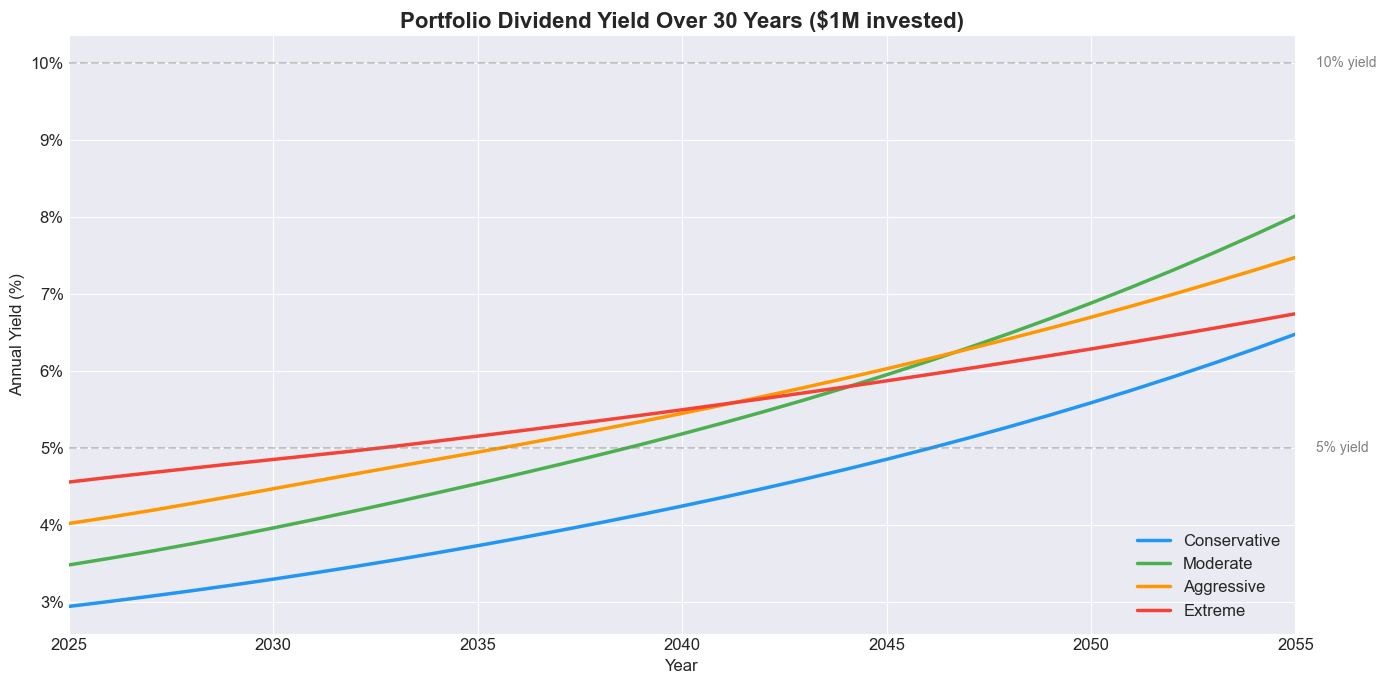


Portfolio yield at key years ($1M invested):
Scenario             Year 1     Year 5    Year 10    Year 20    Year 30
Conservative           2.9%       3.3%       3.7%       4.9%       6.5%
Moderate               3.5%       4.0%       4.5%       6.0%       8.0%
Aggressive             4.0%       4.5%       5.0%       6.0%       7.5%
Extreme                4.6%       4.9%       5.2%       5.9%       6.7%


In [19]:
fig, ax = plt.subplots(figsize=(14, 7))

for scenario_name in SCENARIOS:
    pr = portfolio_results[(scenario_name, 1_000_000)]
    yrs = [yr.year for yr in pr.yearly_results]
    yields = [yr.portfolio_yield for yr in pr.yearly_results]
    ax.plot(yrs, yields, '-', color=colors[scenario_name], linewidth=2.5,
           label=f'{scenario_name.title()}')

# Reference lines
ax.axhline(y=5, color='gray', linestyle='--', alpha=0.4)
ax.text(base_year + 30.5, 5, '5% yield', fontsize=10, color='gray', va='center')
ax.axhline(y=10, color='gray', linestyle='--', alpha=0.4)
ax.text(base_year + 30.5, 10, '10% yield', fontsize=10, color='gray', va='center')

ax.set_title('Portfolio Dividend Yield Over 30 Years ($1M invested)', fontsize=16, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Annual Yield (%)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(fontsize=12)
ax.set_xlim(base_year, base_year + 30)

plt.tight_layout()
plt.show()

# Print summary table
print(f'\nPortfolio yield at key years ($1M invested):')
print(f'{"Scenario":<16} {"Year 1":>10} {"Year 5":>10} {"Year 10":>10} {"Year 20":>10} {"Year 30":>10}')
print('=' * 68)
for scenario_name in SCENARIOS:
    pr = portfolio_results[(scenario_name, 1_000_000)]
    checkpoints = [0, 5, 10, 20, 30]
    vals = [f'{pr.yearly_results[i].portfolio_yield:.1f}%' for i in checkpoints]
    print(f'{scenario_name.title():<16} {vals[0]:>10} {vals[1]:>10} {vals[2]:>10} {vals[3]:>10} {vals[4]:>10}')

## 13. Two Futures — The Argument

Here's the thing about a 90% RIF at Amazon: those people aren't getting jobs somewhere else. It's not just Amazon — it's every company, every industry. If displaced workers have no income, they stop buying. Amazon loses its customers. Revenue collapses. Dividends collapse. Everybody loses.

**The investor model isn't just a nice idea. It's the difference between a functioning economy and a death spiral.**

Same AI adoption. Same companies. Same timeline. The only difference: do displaced workers have investment income, or not?

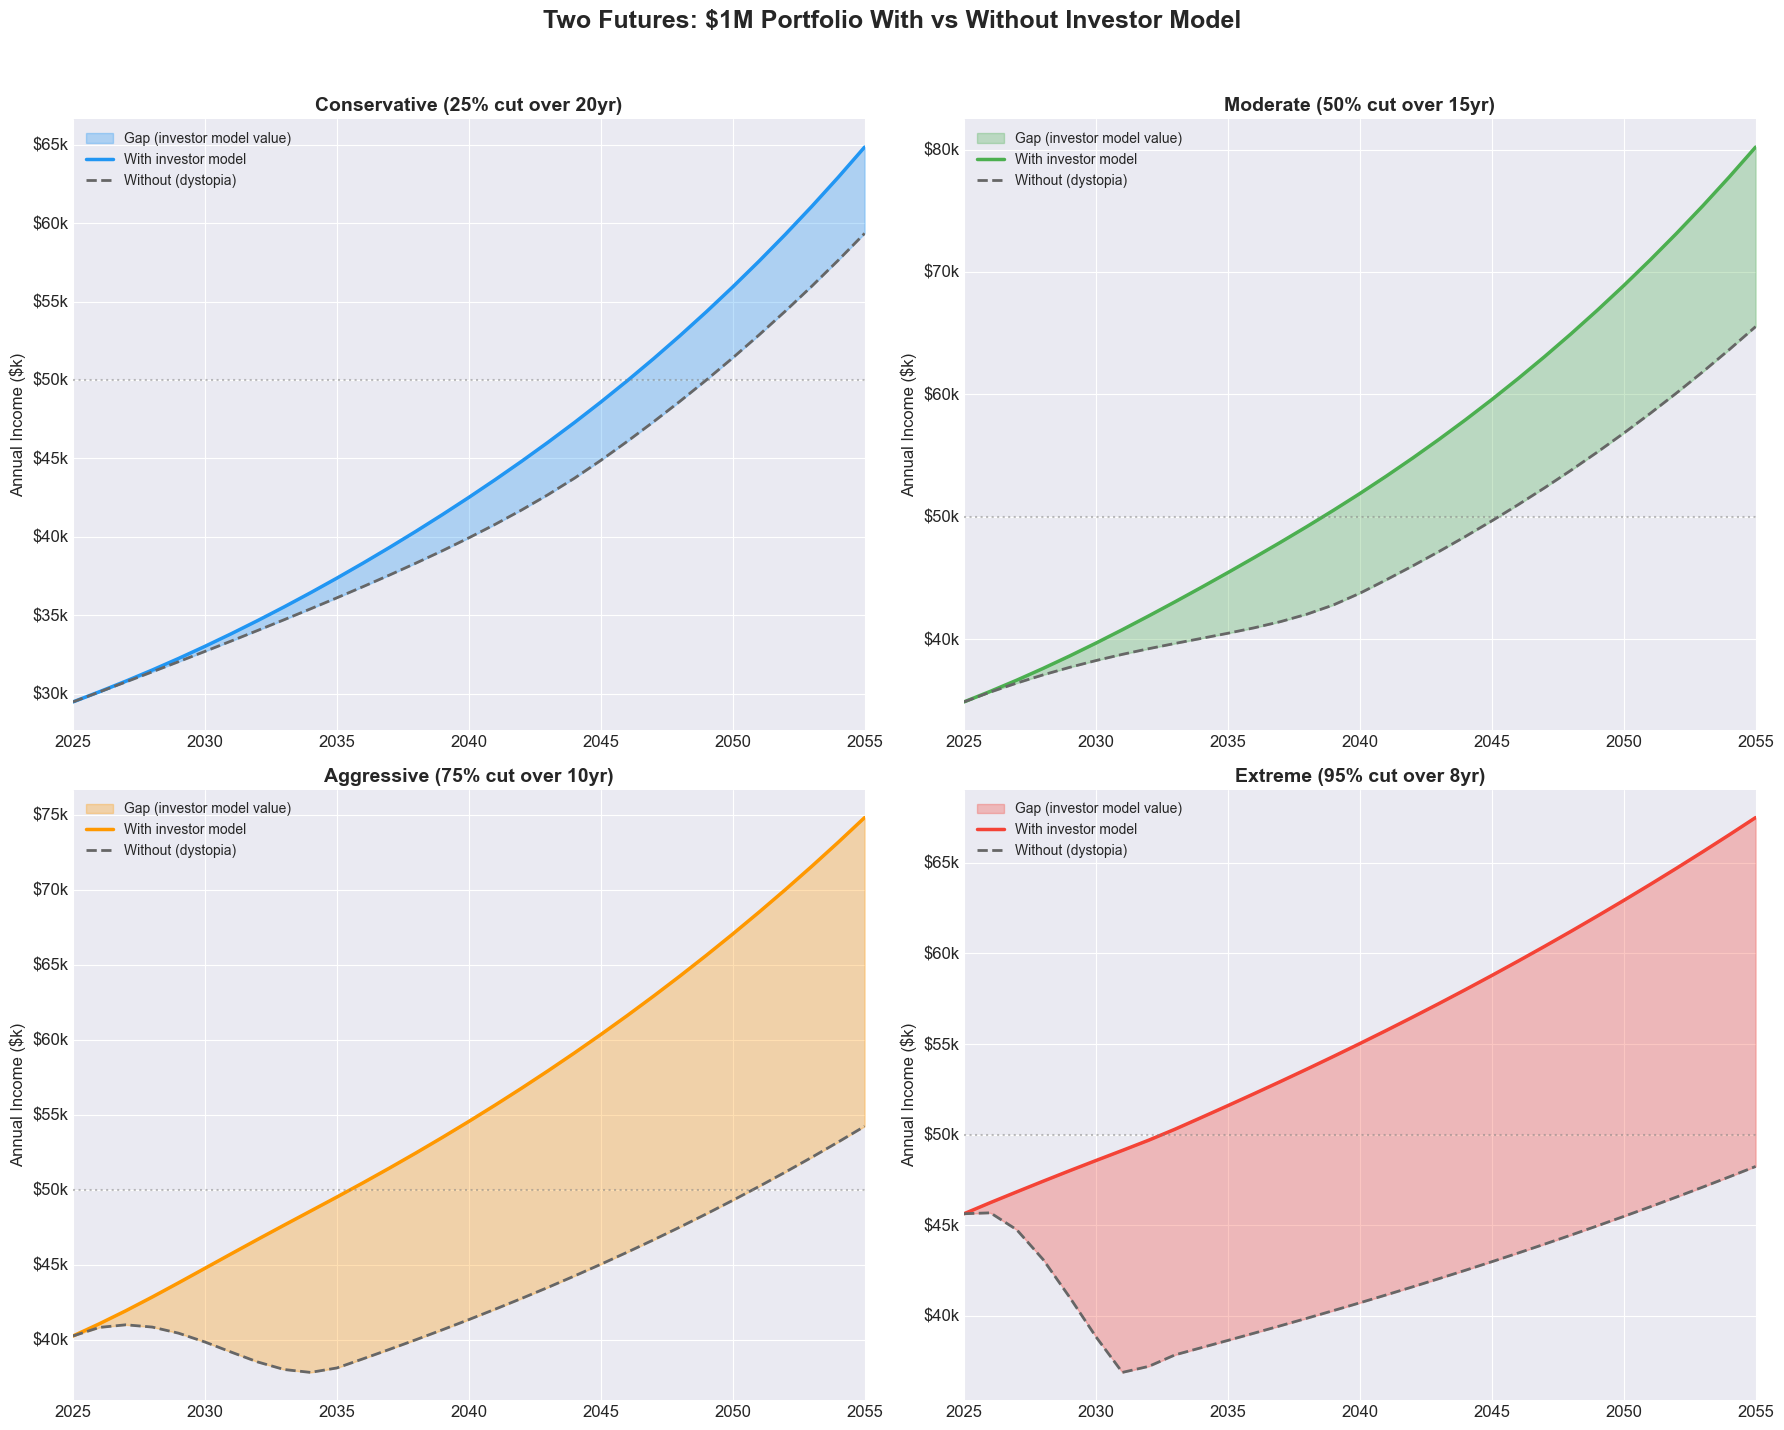


Scenario         With Investors (Yr 30)         Dystopia (Yr 30)            Gap
Conservative   $                  64.8k $                  59.3k $         5.5k
Moderate       $                  80.2k $                  65.5k $        14.7k
Aggressive     $                  74.8k $                  54.2k $        20.6k
Extreme        $                  67.5k $                  48.2k $        19.3k

The gap is the economic cost of NOT having the investor model in place.
In the extreme scenario, it's the difference between a functioning society and collapse.


In [20]:
from src.models.scenario import make_dystopia_variant

# Run both futures for all scenarios
future_results = {}
for scenario_name, params in SCENARIOS.items():
    params.base_year = base_year
    allocs = build_equal_weight_portfolio(PORTFOLIO_COMPANIES, 1_000_000)
    
    # Future 1: With investor model (70% adoption)
    pr_invest = run_portfolio_scenario(params, f'{scenario_name}_invest', allocs)
    
    # Future 2: Without investor model (dystopia — nobody has replacement income)
    dystopia = make_dystopia_variant(params)
    pr_dystopia = run_portfolio_scenario(dystopia, f'{scenario_name}_dystopia', allocs)
    
    future_results[scenario_name] = (pr_invest, pr_dystopia)

# Plot: Two futures side by side for each scenario
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for ax, scenario_name in zip(axes.flat, SCENARIOS):
    pr_invest, pr_dystopia = future_results[scenario_name]
    
    yrs_i = [yr.year for yr in pr_invest.yearly_results]
    income_i = [yr.annual_income / 1000 for yr in pr_invest.yearly_results]
    income_d = [yr.annual_income / 1000 for yr in pr_dystopia.yearly_results]
    
    ax.fill_between(yrs_i, income_d, income_i, alpha=0.3, color=colors[scenario_name],
                   label='Gap (investor model value)')
    ax.plot(yrs_i, income_i, '-', color=colors[scenario_name], linewidth=2.5,
           label='With investor model')
    ax.plot(yrs_i, income_d, '--', color='#666666', linewidth=2,
           label='Without (dystopia)')
    
    # 50k milestone line
    ax.axhline(y=50, color='gray', linestyle=':', alpha=0.5)
    
    pct = SCENARIOS[scenario_name].labor_reduction_pct
    ramp = SCENARIOS[scenario_name].ramp_years
    ax.set_title(f'{scenario_name.title()} ({pct:.0%} cut over {ramp}yr)', 
                fontsize=14, fontweight='bold')
    ax.set_ylabel('Annual Income ($k)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
    ax.legend(fontsize=10)
    ax.set_xlim(base_year, base_year + 30)

fig.suptitle('Two Futures: $1M Portfolio With vs Without Investor Model',
            fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary table
print(f'\n{"Scenario":<14} {"With Investors (Yr 30)":>24} {"Dystopia (Yr 30)":>24} {"Gap":>14}')
print('=' * 78)
for name in SCENARIOS:
    pr_i, pr_d = future_results[name]
    yi = pr_i.yearly_results[30].annual_income
    yd = pr_d.yearly_results[30].annual_income
    gap = yi - yd
    print(f'{name.title():<14} ${yi/1000:>22.1f}k ${yd/1000:>22.1f}k ${gap/1000:>12.1f}k')

print(f'\nThe gap is the economic cost of NOT having the investor model in place.')
print(f'In the extreme scenario, it\'s the difference between a functioning society and collapse.')

## 14. The Deflation Bonus — Everything Gets Cheaper

We've been modeling labor replacement at the company level. But there's a second effect: **everything Amazon buys also gets cheaper.** The factories making products, the trucks shipping them, the warehouses storing them — they're all automating too.

Amazon's non-labor operating costs are ~$452B (goods, shipping, infrastructure). When those suppliers cut their own costs with AI, Amazon's input prices drop. This cascading cost reduction through the supply chain is now included in our scenarios.

**And there's a third effect:** In a world where everything costs less to produce, **consumer prices drop too.** A $75k income in an AI-deflated economy buys what $100k+ buys today. The "living income" threshold is a moving target — and it's moving in your favor.

In [ ]:
# Show the impact of supply chain cost reduction
from dataclasses import replace as dc_replace

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# --- Left: Total income with vs without supply chain ---
ax = axes[0]
for sname in ['moderate', 'aggressive']:
    pr_with = portfolio_results[(sname, 1_000_000)]
    
    # Run without supply chain for comparison
    params_no_sc = dc_replace(SCENARIOS[sname], supply_chain_cost_pct=0.0, base_year=base_year)
    allocs_cmp = build_equal_weight_portfolio(PORTFOLIO_COMPANIES, 1_000_000)
    pr_without = run_portfolio_scenario(params_no_sc, sname, allocs_cmp)
    
    yrs = [yr.year for yr in pr_with.yearly_results]
    income_with = [yr.total_income / 1000 for yr in pr_with.yearly_results]
    income_without = [yr.total_income / 1000 for yr in pr_without.yearly_results]
    
    ax.fill_between(yrs, income_without, income_with, alpha=0.2, color=colors[sname])
    ax.plot(yrs, income_with, '-', color=colors[sname], linewidth=2.5,
           label=f'{sname.title()} (+ supply chain)')
    ax.plot(yrs, income_without, '--', color=colors[sname], linewidth=1.5, alpha=0.6,
           label=f'{sname.title()} (labor only)')

ax.axhline(y=75, color='gray', linestyle=':', alpha=0.4)
ax.text(base_year + 31, 75, '$75k', fontsize=9, color='gray', va='center')
ax.set_title('Supply Chain Adds to Total Income\n($1M Portfolio)', fontsize=13, fontweight='bold')
ax.set_ylabel('Annual Income ($k)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
ax.legend(fontsize=9)
ax.set_xlim(base_year, base_year + 30)

# --- Middle: Savings breakdown for Amazon (moderate, year 30) ---
ax = axes[1]
from src.models.scenario import run_scenario as run_sc
from src.models.labor import estimate_amazon_labor as est_labor
amazon_labor = est_labor(base_year, by_year[base_year])
SCENARIOS['moderate'].base_year = base_year
amazon_result = run_sc(SCENARIOS['moderate'], 'Amazon', by_year[base_year], amazon_labor)
p30 = amazon_result.projections[30]

categories = ['Labor\nSavings', 'AI\nCosts', 'Supply Chain\nSavings', 'Net Total\nSavings']
values = [
    p30.labor_savings / 1e9,
    -p30.ai_compute_cost / 1e9,
    p30.supply_chain_savings / 1e9,
    (p30.labor_savings - p30.ai_compute_cost + p30.supply_chain_savings) / 1e9
]
bar_colors = ['#4CAF50', '#F44336', '#2196F3', '#FF9800']

bars = ax.bar(categories, values, color=bar_colors, alpha=0.85, edgecolor='white', linewidth=2)
ax.axhline(y=0, color='black', linewidth=0.5)
for bar, val in zip(bars, values):
    ypos = val + 3 if val > 0 else val - 8
    ax.text(bar.get_x() + bar.get_width()/2, ypos, f'${val:.0f}B',
           ha='center', fontweight='bold', fontsize=11)

ax.set_title(f'Amazon Cost Savings Breakdown\n(Moderate, Year {p30.year})', fontsize=13, fontweight='bold')
ax.set_ylabel('Billions USD')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))

# --- Right: Purchasing power adjusted income ---
ax = axes[2]
for sname in SCENARIOS:
    pr = portfolio_results[(sname, 1_000_000)]
    params = SCENARIOS[sname]
    yrs = [yr.year for yr in pr.yearly_results]
    
    pp_incomes = []
    for i, yr in enumerate(pr.yearly_results):
        if params.ramp_years > 0:
            rf = min(1.0, i / params.ramp_years)
            sc_ramp = params.supply_chain_cost_pct * (rf ** 2 * (3 - 2 * rf))
        else:
            sc_ramp = params.supply_chain_cost_pct
        price_drop = sc_ramp * (1 - params.margin_retention_pct)
        pp_mult = 1 / (1 - price_drop) if price_drop < 1 else 1
        pp_incomes.append(yr.total_income * pp_mult / 1000)
    
    ax.plot(yrs, pp_incomes, '-', color=colors[sname], linewidth=2.5, label=f'{sname.title()}')

# Nominal reference (moderate)
pr = portfolio_results[('moderate', 1_000_000)]
nominal = [yr.total_income / 1000 for yr in pr.yearly_results]
ax.plot([yr.year for yr in pr.yearly_results], nominal, '--', color='gray', linewidth=1.5,
       label='Moderate (nominal)')

for milestone, ls in [(75, ':'), (100, '-.')]:
    ax.axhline(y=milestone, color='gray', linestyle=ls, alpha=0.4)
    ax.text(base_year + 31, milestone, f'${milestone}k', fontsize=9, color='gray', va='center')

ax.set_title("Purchasing Power Adjusted Income\n(Prices drop as everything gets cheaper)",
            fontsize=13, fontweight='bold')
ax.set_ylabel("Today's Equivalent ($k)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
ax.legend(fontsize=9)
ax.set_xlim(base_year, base_year + 30)

fig.suptitle('The Full Picture: Labor + Supply Chain + Deflation',
            fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary table
print(f'Impact of supply chain + deflation ($1M portfolio, Year 30):')
print(f'\n{"Scenario":<14} {"Labor Only":>14} {"+ Supply Chain":>16} {"+ Purch. Power":>16}')
print('=' * 62)
for sname in SCENARIOS:
    pr_with = portfolio_results[(sname, 1_000_000)]
    
    params_no_sc = dc_replace(SCENARIOS[sname], supply_chain_cost_pct=0.0, base_year=base_year)
    allocs_cmp = build_equal_weight_portfolio(PORTFOLIO_COMPANIES, 1_000_000)
    pr_without = run_portfolio_scenario(params_no_sc, sname, allocs_cmp)
    
    labor_only = pr_without.yearly_results[30].total_income
    with_sc = pr_with.yearly_results[30].total_income
    
    params = SCENARIOS[sname]
    price_drop = params.supply_chain_cost_pct * (1 - params.margin_retention_pct)
    pp_mult = 1 / (1 - price_drop) if price_drop < 1 else 1
    pp_adj = with_sc * pp_mult
    
    print(f'{sname.title():<14} ${labor_only/1000:>12.1f}k ${with_sc/1000:>14.1f}k ${pp_adj/1000:>14.1f}k')

print(f'\nSupply chain savings boost income ~25-30%. Deflation adds ~5-20% in purchasing power.')
print(f'A $1M portfolio reaches $170-200k/yr in real purchasing power by 2055.')

## 15. How Much Do You Need? — The Path to a Living Income

Nobody starts with $1M. People save monthly over a career — $500, $1,000, $2,000/month into an index fund. During the accumulation phase, dividends get reinvested and shares appreciate as AI transforms these companies.

Our 10-company portfolio is a proxy for a **diversified index fund**. The full S&P 500 employs ~30 million people with an estimated ~$4-5 trillion in total labor costs — roughly 10x our sample. An S&P 500 index fund (like VOO or SPY) captures this entire transformation in a single investment.

The question becomes: **if you start saving now, when does your portfolio generate a living income?**

In [ ]:
# Accumulation model: monthly savings with dividend reinvestment
# Extract year-by-year returns from our model
pr_mod = portfolio_results[('moderate', 1_000_000)]

# Compute annual total returns (price appreciation + dividend yield)
scenario_returns = {}
for sname in SCENARIOS:
    pr = portfolio_results[(sname, 1_000_000)]
    rets = []
    for i in range(1, len(pr.yearly_results)):
        prev_val = pr.yearly_results[i-1].portfolio_value
        curr_val = pr.yearly_results[i].portfolio_value
        divs = pr.yearly_results[i].total_dividends
        if prev_val > 0:
            rets.append((curr_val + divs) / prev_val - 1)
        else:
            rets.append(0.07)
    scenario_returns[sname] = rets

monthly_savings = [500, 1000, 2000]
save_colors = ['#2196F3', '#4CAF50', '#FF9800']
save_labels = ['$500/mo', '$1,000/mo', '$2,000/mo']

def simulate_accumulation(monthly, returns, years=30):
    portfolio = 0
    values = [0]
    for yr in range(years):
        ret = returns[yr] if yr < len(returns) else returns[-1]
        portfolio = portfolio * (1 + ret) + monthly * 12
        values.append(portfolio)
    return values

def simulate_flat_rate(monthly, annual_rate, years=30):
    portfolio = 0
    values = [0]
    for yr in range(years):
        portfolio = portfolio * (1 + annual_rate) + monthly * 12
        values.append(portfolio)
    return values

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# --- Left: Portfolio value growth from monthly savings (moderate + historical) ---
ax = axes[0]
years_x = list(range(base_year, base_year + 31))
for monthly, color, label in zip(monthly_savings, save_colors, save_labels):
    values = simulate_accumulation(monthly, scenario_returns['moderate'])
    ax.plot(years_x, [v / 1e6 for v in values], '-', color=color, linewidth=2.5, label=label)

# Historical S&P 500 context: 10% nominal
hist_values = simulate_flat_rate(1000, 0.10)
ax.plot(years_x, [v / 1e6 for v in hist_values], ':', color='gray', linewidth=2,
       label='$1k/mo @ 10% (S&P hist.)')

ax.set_title('Portfolio Growth from Monthly Savings\n(Moderate Scenario)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Portfolio Value ($M)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
ax.legend(fontsize=10)
ax.set_xlim(base_year, base_year + 30)

# --- Middle: Annual income achievable from accumulated portfolio ---
ax = axes[1]
for monthly, color, label in zip(monthly_savings, save_colors, save_labels):
    values = simulate_accumulation(monthly, scenario_returns['moderate'])
    incomes = [v * 0.04 / 1000 for v in values]
    ax.plot(years_x, incomes, '-', color=color, linewidth=2.5, label=label)

# Historical comparison
hist_incomes = [v * 0.04 / 1000 for v in hist_values]
ax.plot(years_x, hist_incomes, ':', color='gray', linewidth=2, label='$1k/mo @ 10% (S&P hist.)')

for milestone, ls in [(50, '--'), (75, ':'), (100, '-.')]:
    ax.axhline(y=milestone, color='gray', linestyle=ls, alpha=0.4, linewidth=1)
    ax.text(base_year + 31, milestone, f'${milestone}k', fontsize=9, color='gray', va='center')

ax.set_title('Annual Income from Savings\n(4% Safe Withdrawal Rate)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Annual Income ($k)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
ax.legend(fontsize=10)
ax.set_xlim(base_year, base_year + 30)

# --- Right: $1,000/mo across all scenarios + historical ---
ax = axes[2]
for sname in SCENARIOS:
    values = simulate_accumulation(1000, scenario_returns[sname])
    incomes = [v * 0.04 / 1000 for v in values]
    ax.plot(years_x, incomes, '-', color=colors[sname], linewidth=2.5, label=f'{sname.title()}')

ax.plot(years_x, hist_incomes, ':', color='gray', linewidth=2, label='10% (S&P historical)')

for milestone, ls in [(50, '--'), (75, ':'), (100, '-.')]:
    ax.axhline(y=milestone, color='gray', linestyle=ls, alpha=0.4, linewidth=1)
    ax.text(base_year + 31, milestone, f'${milestone}k', fontsize=9, color='gray', va='center')

ax.set_title('$1,000/mo Across Scenarios\n(4% SWR on Accumulated Portfolio)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Annual Income ($k)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
ax.legend(fontsize=10)
ax.set_xlim(base_year, base_year + 30)

fig.suptitle('The Accumulation Path: Monthly Savings to Living Income',
            fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary table
print(f'Monthly savings to living income (4% SWR):')
print(f'\n{"":20s} {"Portfolio @15yr":>16} {"Income @15yr":>14} {"Portfolio @25yr":>16} {"Income @25yr":>14}')
print('=' * 82)
for monthly, label in zip(monthly_savings, save_labels):
    values = simulate_accumulation(monthly, scenario_returns['moderate'])
    p15, p25 = values[15], values[25]
    print(f'{label + " (moderate)":<20} ${p15/1e6:>14.2f}M ${p15*0.04/1000:>12.1f}k ${p25/1e6:>14.2f}M ${p25*0.04/1000:>12.1f}k')

# Historical comparison
for monthly, label in zip(monthly_savings, save_labels):
    values = simulate_flat_rate(monthly, 0.10)
    p15, p25 = values[15], values[25]
    print(f'{label + " (S&P hist.)":<20} ${p15/1e6:>14.2f}M ${p15*0.04/1000:>12.1f}k ${p25/1e6:>14.2f}M ${p25*0.04/1000:>12.1f}k')

print(f'\nOur model uses ~7% total return (conservative 4% revenue growth + dividends).')
print(f'Historical S&P 500 returns ~10% nominal (includes ~3% inflation).')
print(f'The gray dotted line shows historical rates — our model is deliberately conservative.')
print(f'\nAt historical S&P rates, $1,000/mo reaches ~$47k/yr in 25 years.')
print(f'Our conservative model: ~$29k. The real number is likely between these.')
print(f'\nThe web version will let you configure revenue growth, AI costs, and payout ratios')
print(f'to explore the full range of outcomes.')

## 16. What This Means

### The demand paradox is the argument

The model shows something critical: **the investor model isn't optional.** Without it, AI labor replacement creates a death spiral — displaced workers stop buying, revenue collapses, profits collapse, dividends collapse. Everyone loses, including the companies and their remaining shareholders.

With the investor model, investment income replaces wage income, demand holds, companies stay profitable, and the system works. The gap between the two futures widens with every year of AI adoption.

### The math — conservatively

This model uses **deliberately conservative assumptions**: 4% revenue growth (below historical norms for these companies), full AI cost accounting, and demand destruction from worker displacement. Even so:

- A **$1M lump-sum portfolio** generates $40k/yr from Day 1, growing to $125k/yr over 30 years
- **$2,000/month** saved over 25 years builds a portfolio generating ~$59-94k/yr (depending on growth assumptions)
- Portfolio values grow from the initial investment to **2-3x** through earnings-driven appreciation
- The S&P 500 index fund is the simplest vehicle — it captures the entire AI labor transformation across 500 companies and ~30M employees

At historical S&P 500 return rates (~10% nominal), these numbers improve significantly. The interactive web version will let you explore the full range of assumptions.

### Capital gains change everything

The dividend-only view understated the thesis. When you include capital gains — which is how people actually invest today — the numbers become dramatically more compelling. Even companies that don't pay dividends (like Amazon today) generate investor income through price appreciation.

### What we're NOT modeling (yet)

- **Reinvestment compounding** — dividends reinvested in early years accelerate the curve dramatically
- **New companies** — AI-native businesses that don't exist yet
- **The full S&P 500** — our 10 companies are a proof of concept; 500 would diversify further
- **Wage premium for remaining human laborers** — the plumber in this world makes $500k/yr

### The real question isn't economic — it's political

The numbers show this *can* work. The question is whether we build the on-ramp:
- Investment access and education *before* mass displacement
- Policy that enables broad ownership (not just today's shareholders capturing the windfall)
- A culture shift from "your job defines you" to "your investments and choices define you"

Class mobility, not class dependency. Agency, not handouts.

**We are not screwed. But only if we choose not to be.**